# NB12: 오토바이 배송 vs 드론·로봇 배송 비교 분석

**목적**: 기존 오토바이 배송과 드론+로봇 배송의 비용·시간·탄소 배출 비교

**비교 지표 (6축 레이더 차트)**:
1. 배송 시간 (분/건)
2. 배송 비용 (원/건)
3. 탄소 배출 (gCO₂/건)
4. 기상 민감도 (1=안전, 0=취약)
5. 야간 운영 (1=가능, 0=불가)
6. 경사지 대응 (1=원활, 0=불가)

**입력**:
- T20 탄소 배출 데이터 (`00_data/민간데이터/T20-*/T20/`)
- `processed/delivery_routes_summary.csv` (NB11)
- `processed/final_hubs.gpkg` (NB10)

**출력**: `processed/mode_comparison.csv`

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

BASE = Path(r"C:\Users\jimin\Desktop\1_BITAmin_16기\1_Seongnam")
OUT = BASE / "processed"
T20_DIR = BASE / "00_data" / "민간데이터"

# T20 탄소 배출 데이터 디렉토리 탐색
t20_dirs = list(T20_DIR.glob("T20-*/T20"))
if t20_dirs:
    t20_path = t20_dirs[0]
    t20_files = sorted(t20_path.glob("T20_GG_TRANS_CARBON_SGG_OUTFLOW_*.csv"))
    print(f"T20 탄소 배출 CSV: {len(t20_files)}개월")
else:
    t20_files = []
    print("⚠ T20 데이터 미발견")

T20 탄소 배출 CSV: 36개월


## 1. T20 탄소 배출 데이터 분석

성남시 교통수단별 월별 탄소 배출량 파악

In [2]:
if t20_files:
    # 최근 12개월 로드
    recent_files = t20_files[-12:]
    dfs = []
    for f in recent_files:
        try:
            df = pd.read_csv(f, encoding="utf-8")
        except:
            df = pd.read_csv(f, encoding="cp949")
        dfs.append(df)
    
    carbon = pd.concat(dfs, ignore_index=True)
    print(f"T20 데이터 로드: {len(carbon)} rows (최근 12개월)")
    print(f"컬럼: {carbon.columns.tolist()}")
    print(f"\n교통수단 구분 (TRANS_GB):")
    print(carbon["TRANS_GB"].value_counts())
    
    # 교통수단별 탄소 배출 집계
    trans_carbon = carbon.groupby("TRANS_GB").agg(
        total_carbon=("CARBON_EMISSIONS", "sum"),
        total_trips=("CNT", "sum"),
        avg_distance=("DISTANCE", "mean"),
    ).reset_index()
    trans_carbon["carbon_per_trip"] = trans_carbon["total_carbon"] / trans_carbon["total_trips"]
    trans_carbon["carbon_per_km"] = trans_carbon["total_carbon"] / (
        trans_carbon["total_trips"] * trans_carbon["avg_distance"] / 1000
    )
    
    print(f"\n교통수단별 탄소 배출:")
    print(trans_carbon.sort_values("carbon_per_trip", ascending=False).to_string(index=False))
else:
    print("T20 데이터 없음 — 문헌 기반 기본값 사용")
    carbon = None

T20 데이터 로드: 2016 rows (최근 12개월)
컬럼: ['ETL_YM ', ' DOW ', ' O_CTY_CD ', ' O_MEGA_NM ', ' O_CTY_NM ', ' O_CENTER_X ', ' O_CENTER_Y ', ' TRANS_GB ', ' CNT ', ' DISTANCE ', ' CARBON_EMISSIONS', 'ETL_YM', 'DOW', 'O_CTY_CD', 'O_MEGA_NM', 'O_CTY_NM', 'O_CENTER_X', 'O_CENTER_Y', 'TRANS_GB', 'CNT', 'DISTANCE', 'CARBON_EMISSIONS']

교통수단 구분 (TRANS_GB):
TRANS_GB
0.0    189
1.0    189
2.0    189
3.0    189
4.0    189
5.0    189
6.0    189
7.0    189
Name: count, dtype: int64

교통수단별 탄소 배출:
 TRANS_GB  total_carbon  total_trips  avg_distance  carbon_per_trip  carbon_per_km
      6.0  3.880732e+08     24706.38    368.061587     15707.408906   42676.034250
      4.0  1.002225e+09    348225.70    138.155767      2878.089882   20832.209475
      5.0  3.805914e+08    374296.97    156.300635      1016.816612    6505.518113
      0.0  1.280333e+11 173018780.60     15.004074       739.996258   49319.688374
      2.0  4.343087e+09  53553506.09     12.331534        81.098085    6576.479665
      1.0  4.967259e+

## 2. 배송 모드별 파라미터 설정

오토바이 vs 드론+로봇의 배송 파라미터 (문헌 + T20 데이터 기반)

In [3]:
# 배송 모드 파라미터 (문헌 기반 + T20 보정)
PARAMS = {
    "motorcycle": {
        "name": "오토바이 배송",
        "speed_kmh": 25,
        "cost_per_delivery": 4500,
        "co2_per_km": 62,
        "avg_delivery_dist_km": 3.0,
        "weather_resilience": 0.4,
        "night_operation": 0.7,
        "slope_capability": 0.9,
    },
    "drone_robot": {
        "name": "드론+로봇 배송",
        "speed_kmh": 60,
        "cost_per_delivery": 2800,
        "co2_per_km": 8,
        "avg_delivery_dist_km": 1.5,
        "weather_resilience": 0.3,
        "night_operation": 0.95,
        "slope_capability": 0.6,
    },
}

# T20 데이터로 승용차 CO2 참고 (이륜차 코드 미존재)
if carbon is not None:
    car_data = carbon[carbon["TRANS_GB"] == 0]
    if len(car_data) > 0:
        car_co2 = car_data["CARBON_EMISSIONS"].sum() / car_data["CNT"].sum()
        car_dist = car_data["DISTANCE"].mean() / 1000
        print(f"T20 승용차 탄소: {car_co2:.0f} gCO2/trip (평균 {car_dist:.1f}km)")

# 건당 탄소 배출 계산
for mode, p in PARAMS.items():
    p["co2_per_delivery"] = p["co2_per_km"] * p["avg_delivery_dist_km"]
    p["delivery_time_min"] = p["avg_delivery_dist_km"] / p["speed_kmh"] * 60
    if mode == "drone_robot":
        p["delivery_time_min"] += 2

print("=== 배송 모드 파라미터 ===")
for mode, p in PARAMS.items():
    name = p["name"]
    t = p["delivery_time_min"]
    c = p["cost_per_delivery"]
    co2 = p["co2_per_delivery"]
    print(f"{name}: 시간={t:.1f}분, 비용={c:,}원, CO2={co2:.1f}g")

T20 승용차 탄소: 740 gCO2/trip (평균 0.0km)
=== 배송 모드 파라미터 ===
오토바이 배송: 시간=7.2분, 비용=4,500원, CO2=186.0g
드론+로봇 배송: 시간=3.5분, 비용=2,800원, CO2=12.0g


## 3. 6축 레이더 차트 (Spider Chart)

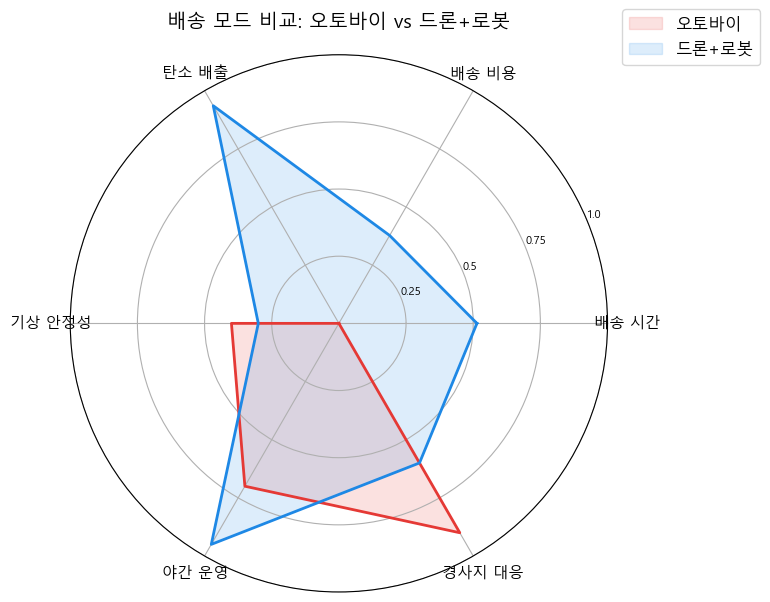

In [4]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 6축 지표 정규화 (0~1, 높을수록 좋음)
metrics = ["배송 시간", "배송 비용", "탄소 배출", "기상 안정성", "야간 운영", "경사지 대응"]

moto = PARAMS["motorcycle"]
drone = PARAMS["drone_robot"]

# 시간/비용/탄소: 작을수록 좋으므로 역수 정규화
max_time = max(moto["delivery_time_min"], drone["delivery_time_min"])
max_cost = max(moto["cost_per_delivery"], drone["cost_per_delivery"])
max_co2 = max(moto["co2_per_delivery"], drone["co2_per_delivery"])

moto_scores = [
    1 - moto["delivery_time_min"] / max_time,  # 시간 (짧을수록 좋음)
    1 - moto["cost_per_delivery"] / max_cost,    # 비용 (저렴할수록 좋음)
    1 - moto["co2_per_delivery"] / max_co2,      # 탄소 (적을수록 좋음)
    moto["weather_resilience"],
    moto["night_operation"],
    moto["slope_capability"],
]

drone_scores = [
    1 - drone["delivery_time_min"] / max_time,
    1 - drone["cost_per_delivery"] / max_cost,
    1 - drone["co2_per_delivery"] / max_co2,
    drone["weather_resilience"],
    drone["night_operation"],
    drone["slope_capability"],
]

# 레이더 차트
angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
angles += angles[:1]  # 닫기

moto_scores += moto_scores[:1]
drone_scores += drone_scores[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.fill(angles, moto_scores, alpha=0.15, color="#E53935", label="오토바이")
ax.plot(angles, moto_scores, color="#E53935", linewidth=2)
ax.fill(angles, drone_scores, alpha=0.15, color="#1E88E5", label="드론+로봇")
ax.plot(angles, drone_scores, color="#1E88E5", linewidth=2)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(["0.25", "0.5", "0.75", "1.0"], fontsize=8)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=12)
ax.set_title("배송 모드 비교: 오토바이 vs 드론+로봇", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

## 4. 월별 탄소 배출 시계열 + 예상 감축 효과

연간 예상 탄소 감축: 5856.3 tCO2
감축률: 94% (드론 전환 건에 대해)
전체 교통 배출 대비: 4.21%


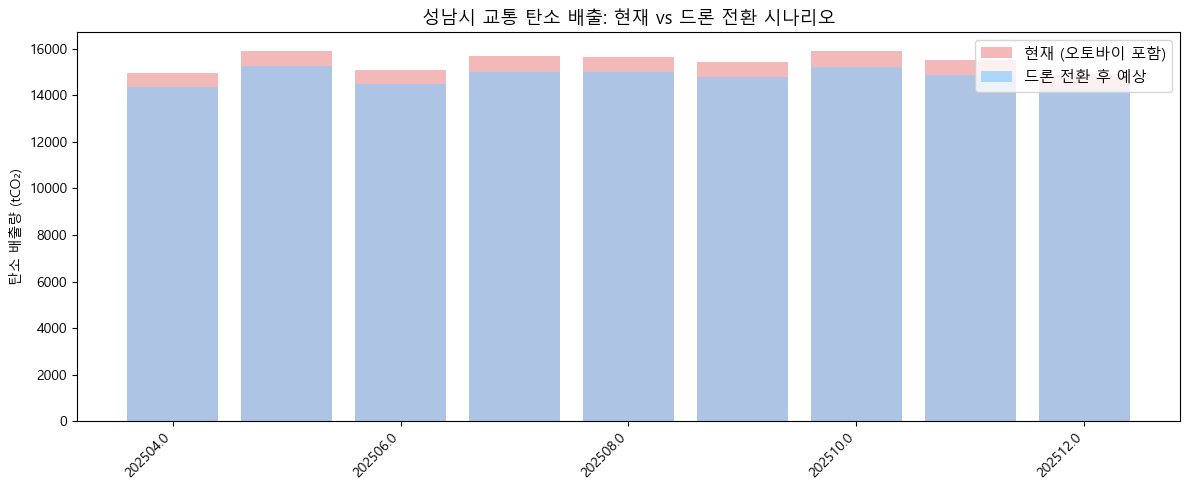

In [5]:
if carbon is not None:
    # 월별 전체 탄소 배출 추이
    monthly_carbon = carbon.groupby("ETL_YM").agg(
        total_carbon=("CARBON_EMISSIONS", "sum"),
        total_trips=("CNT", "sum"),
    ).reset_index()
    monthly_carbon["ETL_YM"] = monthly_carbon["ETL_YM"].astype(str)
    
    # 드론 전환 시 예상 감축량
    # 가정: 배달 비중 약 15%, 그 중 30%를 드론 전환
    DELIVERY_SHARE = 0.15
    DRONE_CONVERSION = 0.30
    CO2_REDUCTION_RATIO = 1 - (drone["co2_per_delivery"] / moto["co2_per_delivery"])
    
    monthly_carbon["projected_reduction"] = (
        monthly_carbon["total_carbon"] 
        * DELIVERY_SHARE * DRONE_CONVERSION * CO2_REDUCTION_RATIO
    )
    monthly_carbon["projected_carbon"] = (
        monthly_carbon["total_carbon"] - monthly_carbon["projected_reduction"]
    )
    
    total_annual_reduction = monthly_carbon["projected_reduction"].sum()
    print(f"연간 예상 탄소 감축: {total_annual_reduction/1e6:.1f} tCO2")
    print(f"감축률: {CO2_REDUCTION_RATIO*100:.0f}% (드론 전환 건에 대해)")
    print(f"전체 교통 배출 대비: {total_annual_reduction/monthly_carbon['total_carbon'].sum()*100:.2f}%")
    
    # 시각화
    fig, ax = plt.subplots(figsize=(12, 5))
    x = range(len(monthly_carbon))
    
    ax.bar(x, monthly_carbon["total_carbon"] / 1e6, color="#EF9A9A", alpha=0.7, label="현재 (오토바이 포함)")
    ax.bar(x, monthly_carbon["projected_carbon"] / 1e6, color="#90CAF9", alpha=0.7, label="드론 전환 후 예상")
    
    ax.set_xticks(x[::2])
    ax.set_xticklabels(monthly_carbon["ETL_YM"].iloc[::2], rotation=45, ha="right")
    ax.set_ylabel("탄소 배출량 (tCO₂)")
    ax.set_title("성남시 교통 탄소 배출: 현재 vs 드론 전환 시나리오", fontsize=13)
    ax.legend(fontsize=11)
    plt.tight_layout()
    plt.show()
else:
    print("T20 데이터 없음 — 시계열 분석 생략")

## 5. 거리 구간별 비교 (바 차트)

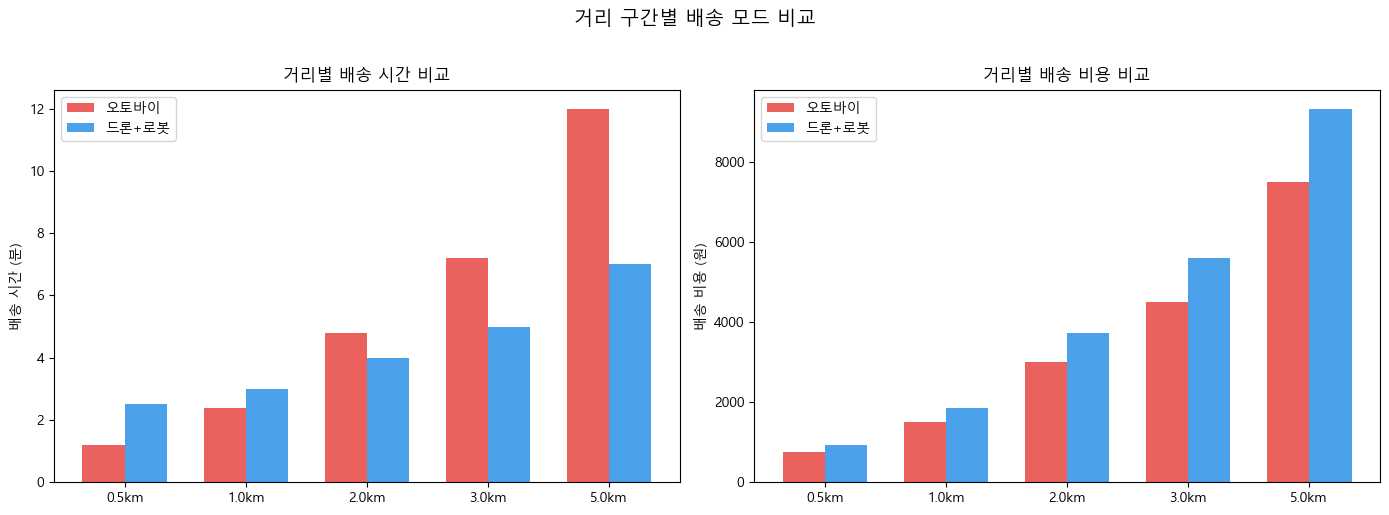


시간 손익분기점: 1.4km (이보다 먼 거리에서 드론이 유리)


In [6]:
# 거리 구간별 배송 시간 비교
dist_bands = [0.5, 1.0, 2.0, 3.0, 5.0]  # km
dist_labels = [f"{d}km" for d in dist_bands]

moto_times = [d / moto["speed_kmh"] * 60 for d in dist_bands]
drone_times = [d / drone["speed_kmh"] * 60 + 2 for d in dist_bands]  # +2분 핸드오프

moto_costs = [moto["cost_per_delivery"] * (d / moto["avg_delivery_dist_km"]) for d in dist_bands]
drone_costs = [drone["cost_per_delivery"] * (d / drone["avg_delivery_dist_km"]) for d in dist_bands]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 배송 시간
x = np.arange(len(dist_bands))
w = 0.35
axes[0].bar(x - w/2, moto_times, w, color="#E53935", alpha=0.8, label="오토바이")
axes[0].bar(x + w/2, drone_times, w, color="#1E88E5", alpha=0.8, label="드론+로봇")
axes[0].set_xticks(x)
axes[0].set_xticklabels(dist_labels)
axes[0].set_ylabel("배송 시간 (분)")
axes[0].set_title("거리별 배송 시간 비교")
axes[0].legend()

# 배송 비용
axes[1].bar(x - w/2, moto_costs, w, color="#E53935", alpha=0.8, label="오토바이")
axes[1].bar(x + w/2, drone_costs, w, color="#1E88E5", alpha=0.8, label="드론+로봇")
axes[1].set_xticks(x)
axes[1].set_xticklabels(dist_labels)
axes[1].set_ylabel("배송 비용 (원)")
axes[1].set_title("거리별 배송 비용 비교")
axes[1].legend()

plt.suptitle("거리 구간별 배송 모드 비교", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# 손익분기점 계산
# 드론이 오토바이보다 빨라지는 거리
# moto_time = d / 25 * 60
# drone_time = d / 60 * 60 + 2
# d/25*60 = d/60*60 + 2 → d*(60/25 - 1) = 2 → d = 2 / (2.4 - 1) = 1.43 km
breakeven_time = 2 / (60/moto["speed_kmh"] - 60/drone["speed_kmh"])
print(f"\n시간 손익분기점: {breakeven_time:.1f}km (이보다 먼 거리에서 드론이 유리)")

## 6. 종합 비교표 + 저장

In [7]:
# 종합 비교표
comparison = pd.DataFrame({
    "지표": [
        "평균 배송 시간 (분)", "평균 배송 비용 (원)", "탄소 배출 (gCO₂/건)",
        "기상 민감도 (1=안전)", "야간 운영 (1=가능)", "경사지 대응 (1=원활)",
        "배송 가능 반경 (km)", "소음 영향", "초기 투자비",
    ],
    "오토바이": [
        f"{moto['delivery_time_min']:.1f}",
        f"{moto['cost_per_delivery']:,}",
        f"{moto['co2_per_delivery']:.0f}",
        f"{moto['weather_resilience']}",
        f"{moto['night_operation']}",
        f"{moto['slope_capability']}",
        "5~10", "높음 (엔진 소음)", "낮음 (200~300만원/대)",
    ],
    "드론+로봇": [
        f"{drone['delivery_time_min']:.1f}",
        f"{drone['cost_per_delivery']:,}",
        f"{drone['co2_per_delivery']:.0f}",
        f"{drone['weather_resilience']}",
        f"{drone['night_operation']}",
        f"{drone['slope_capability']}",
        "1~3 (드론), 0.5 (로봇)", "낮음 (전기모터)", "높음 (5000만원~/스테이션)",
    ],
    "드론 우위": [
        "O" if drone["delivery_time_min"] < moto["delivery_time_min"] else "X",
        "O" if drone["cost_per_delivery"] < moto["cost_per_delivery"] else "X",
        "O" if drone["co2_per_delivery"] < moto["co2_per_delivery"] else "X",
        "X", "O", "X", "-", "O", "X",
    ],
})

print("=== 배송 모드 종합 비교 ===")
print(comparison.to_string(index=False))

# 저장
comparison.to_csv(OUT / "mode_comparison.csv", index=False, encoding="utf-8-sig")

# 레이더 차트용 데이터도 저장
radar_data = pd.DataFrame({
    "metric": metrics,
    "motorcycle": moto_scores[:-1],  # 마지막 닫힘 제거
    "drone_robot": drone_scores[:-1],
})
radar_data.to_csv(OUT / "mode_radar_scores.csv", index=False, encoding="utf-8-sig")

print(f"\n저장 완료:")
print(f"  {OUT / 'mode_comparison.csv'}")
print(f"  {OUT / 'mode_radar_scores.csv'}")

=== 배송 모드 종합 비교 ===
            지표             오토바이              드론+로봇 드론 우위
  평균 배송 시간 (분)              7.2                3.5     O
  평균 배송 비용 (원)            4,500              2,800     O
탄소 배출 (gCO₂/건)              186                 12     O
 기상 민감도 (1=안전)              0.4                0.3     X
  야간 운영 (1=가능)              0.7               0.95     O
 경사지 대응 (1=원활)              0.9                0.6     X
 배송 가능 반경 (km)             5~10 1~3 (드론), 0.5 (로봇)     -
         소음 영향       높음 (엔진 소음)          낮음 (전기모터)     O
        초기 투자비 낮음 (200~300만원/대)  높음 (5000만원~/스테이션)     X

저장 완료:
  C:\Users\jimin\Desktop\1_BITAmin_16기\1_Seongnam\processed\mode_comparison.csv
  C:\Users\jimin\Desktop\1_BITAmin_16기\1_Seongnam\processed\mode_radar_scores.csv
